## Energy Consumption

ในโปรเจกต์นี้เราจะวิเคราะห์ชุดข้อมูลการใช้พลังงานของอาคาร (Building Energy Consumption) โดยข้อมูลประกอบด้วยฟิลด์ต่าง ๆ ดังนี้

* **Site Name** : ตัวแปรชนิดข้อความ, ชื่ออาคาร/สถานที่
* **Department** : ตัวแปรชนิดข้อความ, หน่วยงานหรือภาคส่วนที่อาคารนั้นสังกัด
* **Year** : ตัวแปรเชิงตัวเลข, ปีของข้อมูล
* **Current Solar** : ตัวแปรเชิงตัวเลข, กำลังการผลิตไฟฟ้าจากโซลาร์ที่ติดตั้งแล้ว (kW)
* **Electric Utility** : ตัวแปรชนิดข้อความ, ผู้ให้บริการไฟฟ้าที่อาคารนั้นใช้
* **Electricity Usage** : ตัวแปรเชิงตัวเลข, ปริมาณการใช้ไฟฟ้า (kWh)
* **Peak Electric Demand** : ตัวแปรเชิงตัวเลข, ความต้องการไฟฟ้าสูงสุด (kW)
* **Building Type** : ตัวแปรชนิดข้อความ, ประเภทของอาคาร
* **Building Area** : ตัวแปรเชิงตัวเลข, พื้นที่อาคาร (ตารางฟุต)
* **Natural Gas Usage** : ตัวแปรเชิงตัวเลข, ปริมาณการใช้ก๊าซธรรมชาติ
* **Energy Use Intensity** : ตัวแปรเชิงตัวเลข, ความเข้มของการใช้พลังงานต่อพื้นที่ (EUI)
* **Address** : ตัวแปรชนิดข้อความ, ที่อยู่ของอาคาร
* **Latitude / Longitude** : ตัวแปรเชิงตัวเลข, พิกัดที่ตั้งของอาคาร


มาเริ่มกันด้วยการนำเข้าห้องสมุดสำหรับการวิเคราะห์ข้อมูลและการสร้างกราฟกันเลย


In [2]:
import numpy as np # linear algebra
import pandas as pd
import seaborn as sns# data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Tahoma'        # หรือ 'Leelawadee UI'
plt.rcParams['axes.unicode_minus'] = False

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

***Data Quality and Data Cleanning***

In [6]:
dfr = pd.read_csv("C:/Users/sitti/OneDrive/Desktop/EDA/dataraw/energy-consumption-2020-1.csv")

In [8]:
dfr.head()

,Site Name,Department,Year,Current Solar,Electric Utility,Electricity Usage,Peak Electric Demand,Building Type,Building Area,Natural Gas Usage,Energy Use Intensity,Address,Latitude,Longitude
0,PHX Building 139,Aviation,2020,0,APS,1,0,REPAIRSERVICES,3616,0,0.0,2745 E Air Ln,33.44299,-112.02176
1,Old Verde Park Cntr,Parks,2020,0,APS,12,0,UNKNOWN,0,0,NaN,916 E Van Buren St,33.45205,-112.06179
2,North Ranger Station - Old,Parks,2020,0,APS,77,0,OFFICE,0,0,NaN,11659 N 16th St,33.59485,-112.04768
3,Lookout Mountain Trailhead,Parks,2020,0,APS,242,0,OUTDOORREC,0,0,NaN,15415 N 16th St,33.62720,-112.04820
4,Laveen Basin,Parks,2020,0,SRP,317,0,PARK,0,0,NaN,6039 S 43rd Ave,33.39098,-112.14917


In [9]:
dfr.shape

(496, 14)

In [10]:
dfr.info()

<class 'pandas.DataFrame'>
RangeIndex: 496 entries, 0 to 495
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Site Name             496 non-null    str    
 1   Department            496 non-null    str    
 2   Year                  496 non-null    int64  
 3   Current Solar         496 non-null    int64  
 4   Electric Utility      496 non-null    str    
 5   Electricity Usage     496 non-null    int64  
 6   Peak Electric Demand  496 non-null    int64  
 7    Building Type        496 non-null    str    
 8   Building Area         496 non-null    int64  
 9   Natural Gas Usage     496 non-null    int64  
 10  Energy Use Intensity  280 non-null    float64
 11  Address               496 non-null    str    
 12  Latitude              489 non-null    float64
 13  Longitude             489 non-null    float64
dtypes: float64(3), int64(6), str(5)
memory usage: 54.4 KB


In [11]:
dfr.isna().sum()

Site Name                 0
Department                0
Year                      0
Current Solar             0
Electric Utility          0
Electricity Usage         0
Peak Electric Demand      0
 Building Type            0
Building Area             0
Natural Gas Usage         0
Energy Use Intensity    216
Address                   0
Latitude                  7
Longitude                 7
dtype: int64

In [12]:
dfr.describe()

,Year,Current Solar,Electricity Usage,Peak Electric Demand,Building Area,Natural Gas Usage,Energy Use Intensity,Latitude,Longitude
count,496.0,496.000000,4.960000e+02,496.000000,4.960000e+02,496.000000,280.000000,489.000000,489.000000
mean,2020.0,18.570565,5.360974e+05,194.112903,2.769305e+04,1785.520161,83.157536,33.505784,-112.071781
std,0.0,201.573224,3.454466e+06,1115.499161,1.374057e+05,15412.935269,197.958393,0.101549,0.061346
min,2020.0,0.000000,1.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,33.291660,-112.288850
25%,2020.0,0.000000,2.823350e+04,0.000000,0.000000e+00,0.000000,30.342500,33.438240,-112.107440
50%,2020.0,0.000000,8.811800e+04,38.000000,3.743500e+03,0.000000,46.000000,33.471410,-112.071870
75%,2020.0,0.000000,2.138845e+05,104.500000,1.357475e+04,113.250000,68.562500,33.582570,-112.029420
max,2020.0,4100.000000,6.952790e+07,22957.000000,1.918732e+06,297702.000000,2055.030000,33.806080,-111.746200


In [13]:
dfr.duplicated().sum()

np.int64(3)

In [14]:
dfr.isna().mean() * 100

Site Name                0.000000
Department               0.000000
Year                     0.000000
Current Solar            0.000000
Electric Utility         0.000000
Electricity Usage        0.000000
Peak Electric Demand     0.000000
 Building Type           0.000000
Building Area            0.000000
Natural Gas Usage        0.000000
Energy Use Intensity    43.548387
Address                  0.000000
Latitude                 1.411290
Longitude                1.411290
dtype: float64

In [15]:
dfr['Energy Use Intensity'] = dfr['Energy Use Intensity'].fillna(dfr['Energy Use Intensity'].mean())

In [16]:
dfr[['Latitude', 'Longitude']]

,Latitude,Longitude
0,33.44299,-112.02176
1,33.45205,-112.06179
2,33.59485,-112.04768
3,33.62720,-112.04820
4,33.39098,-112.14917
...,...,...
491,33.44879,-112.07707
492,NaN,NaN
493,33.44981,-112.07045
494,33.43543,-112.00829


In [17]:
dfr[dfr['Latitude'].isna() & dfr['Longitude'].isna()]

,Site Name,Department,Year,Current Solar,Electric Utility,Electricity Usage,Peak Electric Demand,Building Type,Building Area,Natural Gas Usage,Energy Use Intensity,Address,Latitude,Longitude
85,GY Building 56,Aviation,2020,0,APS,15067,0,UNKNOWN,0,0,83.157536,1658 S Litchfield Rd,NaN,NaN
129,GY ST Hanger,Aviation,2020,0,APS,30904,0,HANGAR,0,0,83.157536,1658 S Litchfield Rd,NaN,NaN
221,GY TH2,Aviation,2020,0,APS,71832,21,UNKNOWN,0,0,83.157536,1658 S Litchfield Rd,NaN,NaN
316,GY Building 48,Aviation,2020,0,APS,139738,44,UNKNOWN,0,0,83.157536,1658 S Litchfield Rd,NaN,NaN
374,GY Terminal,Aviation,2020,0,APS,224594,27,TRANSPORTATIONTE,0,0,83.157536,1658 S Litchfield Rd,NaN,NaN
465,GY Building 18,Aviation,2020,0,APS,1134418,273,UNKNOWN,0,0,83.157536,1658 S Litchfield Rd,NaN,NaN
492,PHX SkyTrain Switch Yard,Aviation,2020,0,APS,12540154,2189,TRANSPORTATIONTE,0,0,83.157536,333 S 42nd St,NaN,NaN


In [18]:
dfr = dfr.dropna(subset=['Latitude', 'Longitude'], how='all')

In [19]:
(dfr['Energy Use Intensity'] == 0).sum()

np.int64(1)

In [20]:
(dfr == 0).sum().sum()

np.int64(1161)

In [52]:
dfr.head()

,Site Name,Department,Year,Current Solar,Electric Utility,Electricity Usage,Peak Electric Demand,Building Type,Building Area,Natural Gas Usage,Energy Use Intensity,Address,Latitude,Longitude
0,PHX Building 139,Aviation,2020,0,APS,1,0,REPAIRSERVICES,3616,0,0.000000,2745 E Air Ln,33.44299,-112.02176
1,Old Verde Park Cntr,Parks,2020,0,APS,12,0,UNKNOWN,0,0,83.157536,916 E Van Buren St,33.45205,-112.06179
2,North Ranger Station - Old,Parks,2020,0,APS,77,0,OFFICE,0,0,83.157536,11659 N 16th St,33.59485,-112.04768
3,Lookout Mountain Trailhead,Parks,2020,0,APS,242,0,OUTDOORREC,0,0,83.157536,15415 N 16th St,33.62720,-112.04820
4,Laveen Basin,Parks,2020,0,SRP,317,0,PARK,0,0,83.157536,6039 S 43rd Ave,33.39098,-112.14917


***Exploratory Data Analysis***


In [51]:
#Reading the data
df = pd.read_csv("C:/Users/sitti/OneDrive/Desktop/EDA/data/energy-consumption.csv")

In [22]:
df['Department'].value_counts()

Department
Parks             220
Fire               69
Aviation           62
Public Works       26
Police             24
Housing            22
Library            16
Public Transit     14
Human Services     12
Convention          8
Streets             5
Golf                5
Neighborhood        3
Arts                2
City Clerk          1
Name: count, dtype: int64

การนับจำนวนอาคารในแต่ละหน่วยงาน (Department) เพื่อดูว่าโครงสร้างของข้อมูลกระจุกตัวอยู่ที่ส่วนไหนมากที่สุด

In [23]:
df['Electric Utility'].value_counts()

Electric Utility
APS        348
SRP        139
APS/SRP      2
Name: count, dtype: int64

นับจำนวนอาคารแยกตามผู้ให้บริการไฟฟ้า (Electric Utility) เพื่อดูว่าอาคารส่วนใหญ่ใช้ไฟฟ้าจากผู้ให้บริการรายใด

In [24]:
by_dept = df.groupby('Department')['Electricity Usage'].sum().sort_values(ascending=False)
(by_dept / by_dept.sum() * 100).round(1)

Department
Aviation          45.8
Public Works      11.9
Convention         9.4
Parks              8.6
Police             7.5
Fire               5.8
Housing            3.1
Library            2.6
Human Services     2.3
Arts               1.7
Streets            0.4
Public Transit     0.4
Neighborhood       0.2
City Clerk         0.2
Golf               0.1
Name: Electricity Usage, dtype: float64

รวมปริมาณการใช้ไฟฟ้าทั้งหมด (`Electricity Usage`) แยกตาม Department แล้วเทียบเป็นสัดส่วนเปอร์เซ็นต์ของทั้งชุดข้อมูล เพื่อดูว่าหน่วยงานใดใช้พลังงานรวมมากที่สุด

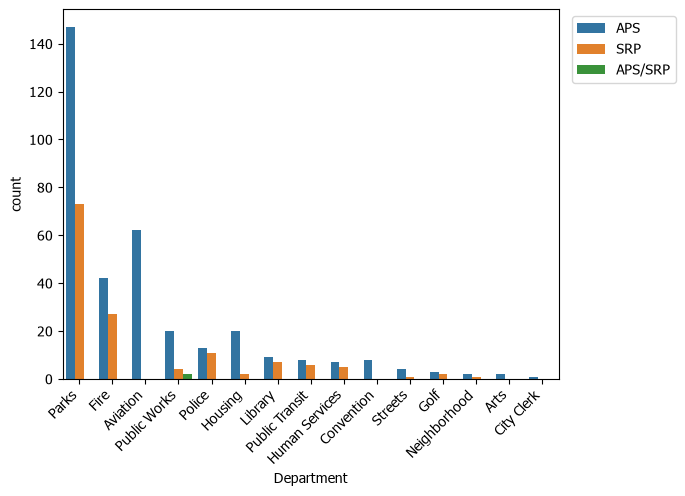

In [25]:
order = df['Department'].value_counts().index

sns.countplot(x='Department', hue='Electric Utility', data=df, order=order)
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.25, 1))

กราฟแท่งแสดงจำนวนอาคาร โดยแยกสีตามผู้ให้บริการไฟฟ้า (hue) และเรียงลำดับตามจำนวนอาคาร เพื่อดูว่าแต่ละ Department กระจายการใช้บริการไฟฟ้าอย่างไร และมีความสัมพันธ์ระหว่างสองตัวแปรนี้หรือไม่

In [26]:
df.columns = df.columns.str.strip()

grp = 'Building Type'
col = 'Energy Use Intensity'

mean = df.groupby(grp)[col].transform('mean')
std  = df.groupby(grp)[col].transform('std')

df['z'] = (df[col] - mean) / std

df[df['z'] > 2].sort_values('z', ascending=False)[['Site Name', grp, col, 'z']].head(10)

,Site Name,Building Type,Energy Use Intensity,z
440,Japanese Friendship Garden,PARK,1556.30,10.692450
396,Fire Station 41,FIRESTATION,142.99,4.197607
421,Paradise Valley Pools,SWIMMINGPOOL,366.23,3.896485
453,Fillmore Gardens,MULTIHOUSING,485.00,3.888883
473,Adams St Garage,PARKING,661.96,3.844065
187,Metrocenter Park & Ride,TRANSPORTATIONTE,2055.03,2.877900
438,Reach 11 Soccer Bldg,PARK,486.23,2.841906
279,Fire Station 20,FIRESTATION,112.65,2.615716
482,Family Advocacy Center,OFFICE,133.32,2.556133
271,Salt River SC Storage,WAREHOUSE-UNREFR,147.74,2.287508


เปรียบเทียบ EUI ของแต่ละอาคารกับค่าเฉลี่ยของ (Building Type) แล้วหารด้วยส่วนเบี่ยงเบนมาตรฐาน ค่า z ที่มากกว่า 2 หมายความว่าอาคารนั้นใช้พลังงานหนาแน่นกว่าอาคารประเภทเดียวกันอย่างมีนัยสำคัญ

Text(0.5, 1.0, 'Top 10 อาคารที่ EUI สูงผิดปกติ')

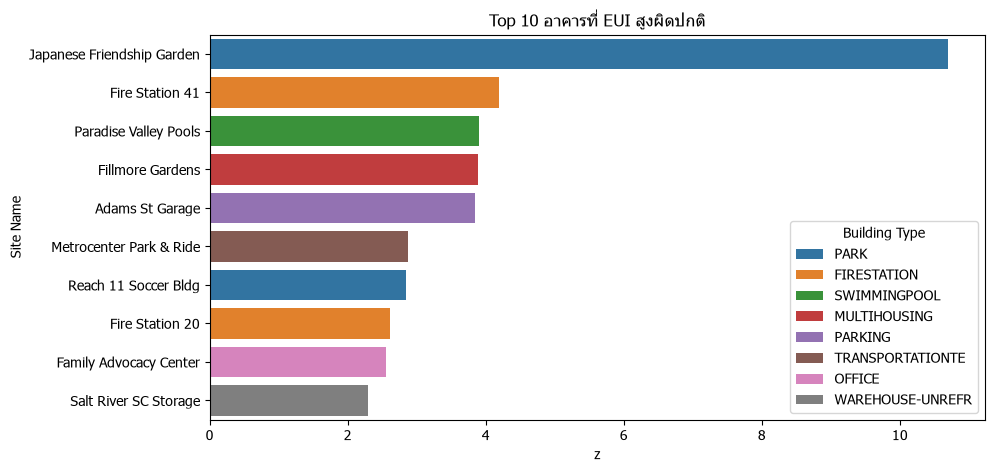

In [27]:
out = df[df['z'] > 2].sort_values('z', ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x='z', y='Site Name', hue='Building Type', data=out)
plt.title('Top 10 อาคารที่ EUI สูงผิดปกติ')

อาคารที่ผิดปกติ 10 อันดับแรกมาแสดงเป็นกราฟแท่ง เพื่อให้เห็นภาพชัดว่าค่า z อันไหนสูงที่สุด

In [28]:
df.columns = df.columns.str.strip()

has_solar = df['Current Solar'] > 0
adoption = has_solar.mean() * 100

print(f'อาคารที่มีโซลาร์: {has_solar.sum()} / {len(df)}')
print(f'คิดเป็น {adoption:.2f}% ของอาคารทั้งหมด')

อาคารที่มีโซลาร์: 33 / 489
คิดเป็น 6.75% ของอาคารทั้งหมด


มีอาคารกี่แห่งที่ติดตั้งโซลาร์แล้ว โดยนับเป็นจำนวนและคิดเป็นเปอร์เซ็นต์ของอาคารทั้งหมด

<Axes: title={'center': 'สัดส่วนอาคารที่มีโซลาร์'}>

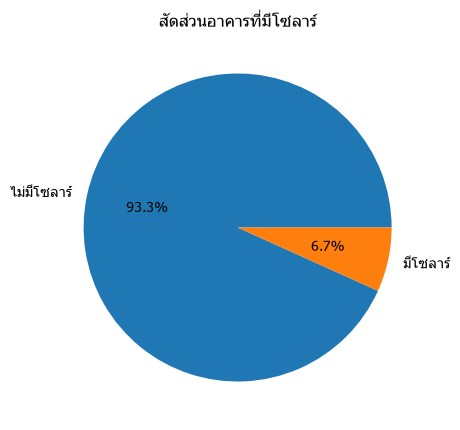

In [29]:
has = df['Current Solar'] > 0
counts = has.map({True: 'มีโซลาร์', False: 'ไม่มีโซลาร์'}).value_counts()

counts.plot.pie(autopct='%.1f%%', ylabel='', figsize=(5,5),
                title='สัดส่วนอาคารที่มีโซลาร์')

แสดงผลเป็นกราฟวงกลมเพื่อให้เห็นสัดส่วนอาคารที่มีและไม่มีโซลาร์ได้ในภาพเดียว

In [30]:
df.columns = df.columns.str.strip()

u = df.groupby('Electric Utility').agg(
    buildings=('Site Name','count'),
    usage=('Electricity Usage','sum'),
    peak=('Peak Electric Demand','sum'))
u['usage %'] = u['usage'] / u['usage'].sum() * 100
u['peak %']  = u['peak']  / u['peak'].sum()  * 100
print(u.sort_values('usage', ascending=False))

                  buildings      usage   peak    usage %     peak %
Electric Utility                                                   
APS                     348  224337221  74699  89.111952  79.699336
SRP                     139   27269416  18933  10.832045  20.200371
APS/SRP                   2     140986     94   0.056003   0.100292


เราสรุปข้อมูลรายผู้ให้บริการไฟฟ้า โดยรวมจำนวนอาคาร ผลรวมการใช้ไฟฟ้า และผลรวมความต้องการไฟฟ้าสูงสุด แล้วคำนวณสัดส่วนเปอร์เซ็นต์ของแต่ละราย เทียบให้เห็นว่าผู้ให้บริการรายใดรองรับปริมาณการใช้ไฟและ Load สูงสุด

In [31]:
df.columns = df.columns.str.strip()
df.shape

(489, 15)

ตรวจสอบขนาดของข้อมูล (จำนวนแถวและคอลัมน์) เพื่อยืนยันว่าโหลดข้อมูลครบถ้วน

## Model Building

ในส่วนนี้เราจะสร้างโมเดล Machine Learning เพื่อ **พยากรณ์ปริมาณการใช้ไฟฟ้า (`Electricity Usage`)** จากคุณลักษณะอื่น ๆ ของอาคาร

เนื่องจาก `Electricity Usage` มีการกระจายแบบเบ้ขวา (อาคารส่วนใหญ่ใช้ไฟน้อย แต่มีอาคารยักษ์บางแห่งที่ใช้ไฟมหาศาล) เราจึงแปลงค่าเป้าหมายด้วย `log1p` เพื่อให้โมเดลเรียนรู้ได้เสถียรขึ้น แล้วค่อยแปลงกลับด้วย `expm1` เมื่อประเมินผล

นอกจากนี้เราจะกรองเฉพาะอาคารที่มี `Building Area > 0` เพราะอาคารที่ไม่มีพื้นที่ย่อมไม่มีความหมายต่อการวิเคราะห์

In [32]:
d = df[df['Building Area'] > 0].copy()
len(d)

280

เลือกเฉพาะอาคารที่มีพื้นที่มากกว่า 0 และเก็บเป็น DataFrame ใหม่ชื่อ `d` แล้วนับว่ามีทั้งหมดกี่อาคาร

In [33]:
cat = ['Department', 'Building Type', 'Electric Utility']
num = ['Building Area', 'Peak Electric Demand', 'Current Solar', 'Latitude', 'Longitude']

X = d[cat + num]
y = np.log1p(d['Electricity Usage'])

แบ่ง Features ออกเป็น 2 กลุ่ม

* **Categorical**: `Department`, `Building Type`, `Electric Utility` — ต้องแปลงเป็น Dummy Variables ก่อน (sklearn ไม่เข้าใจข้อความ)
* **Numerical**: `Building Area`, `Peak Electric Demand`, `Current Solar`, `Latitude`, `Longitude` — ใช้ค่าตัวเลขได้เลย

ตัวแปรเป้าหมาย `y` คือ `log1p(Electricity Usage)` เพื่อลดความเบ้ของข้อมูล

### Train Test Split

แบ่งข้อมูลเป็นชุด Train 80% และ Test 20% โดยใช้ `random_state=42` เพื่อให้ผลลัพธ์ทำซ้ำได้ เราจะ Fit โมเดลบน Train และประเมินบน Test ที่โมเดลไม่เคยเห็น

In [34]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
Xtr.shape, Xte.shape

((224, 8), (56, 8))

ใช้ `ColumnTransformer` เพื่อจัดการ Features ทั้งสองกลุ่มพร้อมกันใน Pipeline เดียว โดย `OneHotEncoder(handle_unknown='ignore')` จะแปลงตัวแปร Categorical เป็นตัวเลข และคอลัมน์ Numerical ปล่อยผ่านไปตามเดิม (`passthrough`) การทำแบบนี้ช่วยป้องกันข้อมูลรั่วไหล (data leakage) เพราะตัว Encoder จะถูก Fit เฉพาะบนข้อมูล Train

In [35]:
pre = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat),
    ('num', 'passthrough', num)
])

เราประกอบทุกอย่างเป็น `Pipeline` เดียว ประกอบด้วยขั้นตอน Preprocessing (`pre`) ตามด้วยตัวโมเดล `RandomForestRegressor`

Random Forest รวมต้นไม้ตัดสินใจหลายร้อยต้นเข้าด้วยกัน ทำให้ทนต่อ Overfitting และจับความสัมพันธ์แบบไม่เป็นเชิงเส้นได้ดี เหมาะกับข้อมูลตารางแบบนี้

In [36]:
rf = Pipeline([
    ('pre', pre),
    ('model', RandomForestRegressor(n_estimators=300, random_state=42))
])
rf

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output o

ฝึกโมเดลบนข้อมูล Train เมื่อเรียก `rf.fit` ทั้ง Preprocessing และการเทรน Random Forest จะเกิดขึ้นภายใน Pipeline ให้อัตโนมัติ

In [37]:
rf.fit(Xtr, ytr)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Department','Building Type','Electric Utility',...,'Current Solar', 'Latitude','Longitude']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset

ทำนายบนชุด Test แล้วแปลงค่ากลับจากสเกล log ด้วย `np.expm1` เพื่อให้ได้หน่วย kWh จริง จากนั้นแปลงค่าจริง `yte` กลับเช่นเดียวกันเพื่อนำมาเปรียบเทียบกันได้

In [38]:
pred_log = rf.predict(Xte)
pred = np.expm1(pred_log)     # แปลงกลับสเกลจริง
true = np.expm1(yte)

### Predictions and Evaluation

เราประเมินโมเดลด้วยตัวชี้วัด 3 ตัว

* **R²**: สัดส่วนความแปรปรวนของการใช้ไฟฟ้าที่โมเดลอธิบายได้ (ยิ่งใกล้ 1 ยิ่งดี)
* **MAE (Mean Absolute Error)**: ค่าคลาดเคลื่อนสัมบูรณ์เฉลี่ย
* **RMSE (Root Mean Squared Error)**: ค่าคลาดเคลื่อนกำลังสองเฉลี่ย (ลงโทษความผิดพลาดใหญ่มากกว่า MAE)

In [39]:
print('R2  :', round(r2_score(true, pred), 3))
print('MAE :', round(mean_absolute_error(true, pred), 1))
print('RMSE:', round(np.sqrt(mean_squared_error(true, pred)), 1))

R2  : 0.955
MAE : 169442.5
RMSE: 411678.3


## Clustering

จากโมเดลพยากรณ์ มาต่อกันที่การ **จัดกลุ่มอาคาร (Clustering)** ด้วย KMeans เพื่อค้นหาว่าอาคารในชุดข้อมูลสามารถแบ่งออกเป็นกลุ่มตามพฤติกรรมการใช้พลังงานได้กี่กลุ่ม และแต่ละกลุ่มมีลักษณะอย่างไร

In [40]:
cols = ['Electricity Usage', 'Peak Electric Demand',
        'Building Area', 'Energy Use Intensity', 'Natural Gas Usage']
df[cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Electricity Usage,489.0,514821.314928,3.435986e+06,1.0,28187.00,87439.000000,211824.000000,69527895.00
Peak Electric Demand,489.0,191.668712,1.119685e+03,0.0,0.00,38.000000,104.000000,22957.00
Building Area,489.0,28089.474438,1.383474e+05,0.0,0.00,3772.000000,13700.000000,1918732.00
Energy Use Intensity,489.0,83.157536,1.496808e+02,0.0,41.19,83.157536,83.157536,2055.03
Natural Gas Usage,489.0,1811.079755,1.552159e+04,0.0,0.00,0.000000,165.000000,297702.00


เริ่มจากการสรุปสถิติพื้นฐาน (ค่าเฉลี่ย, ส่วนเบี่ยงเบนมาตรฐาน, Min/Max, Quartile) ของตัวแปรที่เกี่ยวข้องกับการใช้พลังงาน เพื่อดูช่วงและสเกลของข้อมูลก่อนนำไปจัดกลุ่ม

In [41]:
c = df[(df['Building Area'] > 0) & (df['Energy Use Intensity'] > 0)].copy()
c[cols] = c[cols].fillna(0)
len(c)

279

กรองเฉพาะอาคารที่มีพื้นที่และ EUI มากกว่า 0 (ค่าที่เป็น 0 หรือติดลบไม่มีความหมายในเชิงกายภาพ) แล้วเติมค่าว่างที่เหลือด้วย 0

In [42]:
scaler = StandardScaler()
Z = scaler.fit_transform(c[cols])
Z.shape

(279, 5)

KMeans คำนวณระยะห่างระหว่างจุด จึงต้อง **Standardize** ข้อมูลก่อน เพื่อไม่ให้ตัวแปรที่มีสเกลใหญ่ (เช่น `Electricity Usage`) ครอบงำตัวแปรที่มีสเกลเล็กกว่า `StandardScaler` จะปรับทุกคอลัมน์ให้มีค่าเฉลี่ย 0 และส่วนเบี่ยงเบนมาตรฐาน 1

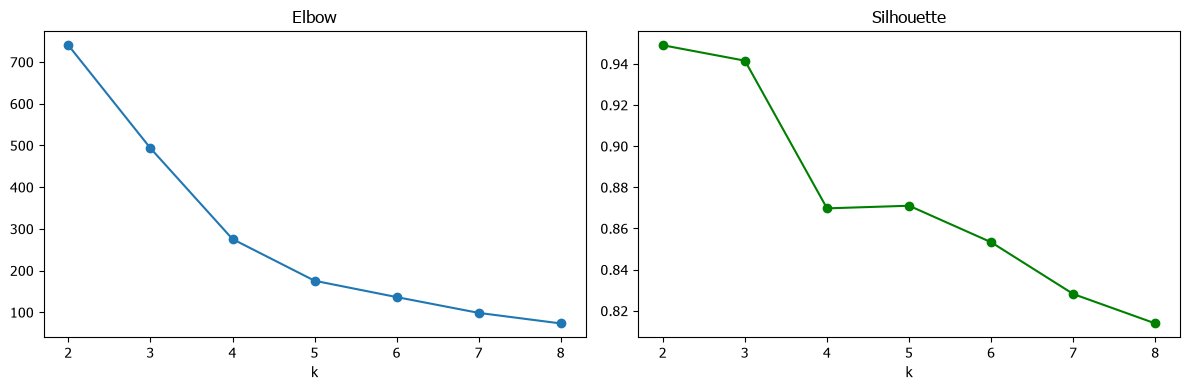

In [43]:
inertia, sil = [], []
ks = range(2, 9)
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Z)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(Z, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(list(ks), inertia, 'o-'); ax[0].set_title('Elbow'); ax[0].set_xlabel('k')
ax[1].plot(list(ks), sil, 'o-', color='green'); ax[1].set_title('Silhouette'); ax[1].set_xlabel('k')
plt.tight_layout()

เราลองจำนวนคลัสเตอร์ `k` ตั้งแต่ 2 ถึง 8 แล้วประเมินด้วย 2 วิธี

* **Elbow Method (Inertia)**: ยิ่ง k มาก ค่า Inertia ยิ่งลดลง เรามองหาจุดที่กราฟเริ่ม "หักข้อศอก" คือจุดที่เพิ่ม k แล้วไม่ช่วยลดความคลาดเคลื่อนมากนัก
* **Silhouette Score**: วัดว่าจุดถูกจัดเข้าคลัสเตอร์ได้กระชับและแยกจากคลัสเตอร์อื่นดีแค่ไหน (ยิ่งสูงยิ่งดี)

In [44]:
k = 5
km = KMeans(n_clusters=k, n_init=10, random_state=42)
c['cluster'] = km.fit_predict(Z)
c['cluster'].value_counts().sort_index()

cluster
0    264
1      6
2      1
3      1
4      7
Name: count, dtype: int64

เลือก `k = 5` เป็นจำนวนคลัสเตอร์ แล้ว Fit KMeans อีกครั้งพร้อมบันทึกป้ายคลัสเตอร์ของแต่ละอาคารลงคอลัมน์ `cluster` จากนั้นนับจำนวนอาคารในแต่ละกลุ่ม

In [45]:
summary = c.groupby('cluster')[cols].mean().round(1)
summary['n'] = c['cluster'].value_counts().sort_index()
summary

,Electricity Usage,Peak Electric Demand,Building Area,Energy Use Intensity,Natural Gas Usage,n
cluster,,,,,,
0,367852.2,148.7,26210.4,54.7,818.3,264
1,7208013.5,1768.3,518919.8,79.2,50718.3,6
2,14342114.0,3770.0,1766280.0,42.4,297702.0,1
3,69527895.0,22957.0,1918732.0,115.4,31382.0,1
4,495310.0,116.7,2007.9,1172.7,179.1,7


สรุปค่าเฉลี่ยของตัวแปรพลังงานในแต่ละคลัสเตอร์ พร้อมจำนวนอาคาร (`n`) เพื่อให้เห็นโปรไฟล์ของแต่ละกลุ่มว่าเป็นอาคารแบบใด

In [46]:
pd.crosstab(c['cluster'], c['Department'])

Department,Arts,Aviation,City Clerk,Convention,Fire,Golf,Housing,Human Services,Library,Neighborhood,Parks,Police,Public Transit,Public Works,Streets
cluster,,,,,,,,,,,,,,,
0,1,40,1,1,69,4,10,12,14,2,65,20,3,18,4
1,1,1,0,0,0,0,1,0,1,0,0,1,0,1,0
2,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,1,0,5,1,0


ใช้ตาราง Cross-tabulation เทียบคลัสเตอร์กับ Department เพื่อดูว่าแต่ละกลุ่มสัมพันธ์กับหน่วยงานใดเป็นพิเศษหรือไม่

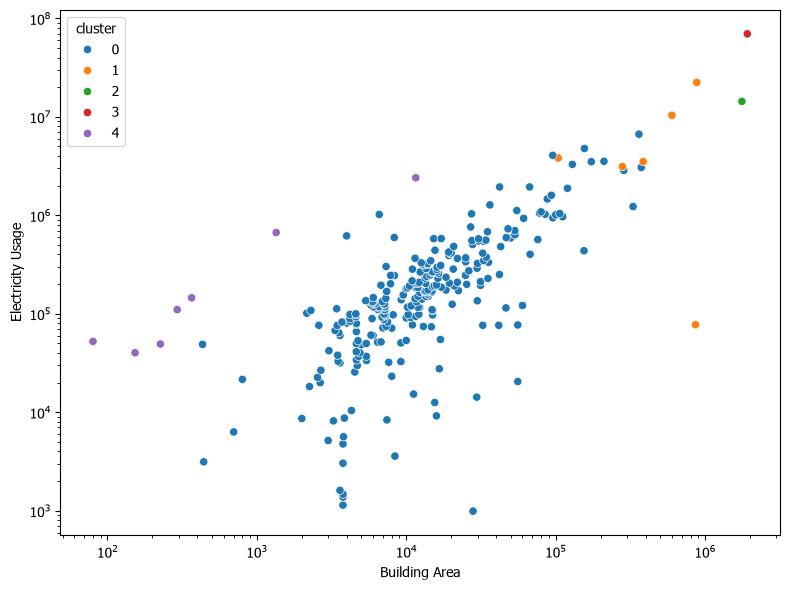

In [47]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Building Area', y='Electricity Usage',
                hue='cluster', palette='tab10', data=c)
plt.xscale('log'); plt.yscale('log')
plt.tight_layout()

วาด Scatter plot ระหว่างพื้นที่อาคาร (`Building Area`) กับปริมาณการใช้ไฟฟ้า (`Electricity Usage`) โดยใช้สีแยกตามคลัสเตอร์ และใช้สเกล log ทั้งสองแกน เพราะข้อมูลกระจายตัวกว้างมาก กราฟนี้ช่วยให้เห็นว่าคลัสเตอร์ต่าง ๆ แยกออกจากกันตามขนาดและการใช้ไฟอย่างไร

In [48]:
prof = c.groupby('cluster')[cols].mean()
prof['n'] = c['cluster'].value_counts().sort_index()
prof.round(1)

,Electricity Usage,Peak Electric Demand,Building Area,Energy Use Intensity,Natural Gas Usage,n
cluster,,,,,,
0,367852.2,148.7,26210.4,54.7,818.3,264
1,7208013.5,1768.3,518919.8,79.2,50718.3,6
2,14342114.0,3770.0,1766280.0,42.4,297702.0,1
3,69527895.0,22957.0,1918732.0,115.4,31382.0,1
4,495310.0,116.7,2007.9,1172.7,179.1,7


คำนวณโปรไฟล์ (ค่าเฉลี่ย) ของแต่ละคลัสเตอร์อีกครั้ง เพื่อใช้เป็น input ให้ฟังก์ชันติดป้ายชื่อกลุ่มในขั้นตอนถัดไป

In [49]:
def label_cluster(row, prof_all):
    # เทียบกับค่ามัธยฐานรวม
    a_med = prof_all['Building Area'].median()
    u_med = prof_all['Electricity Usage'].median()
    e_med = prof_all['Energy Use Intensity'].median()

    area, use, eui = row['Building Area'], row['Electricity Usage'], row['Energy Use Intensity']
    if area < a_med and eui > e_med:
        return 'เล็กแต่ใช้ไฟหนาแน่น'
    if use > u_med * 5:
        return 'อาคารยักษ์กินไฟหนัก'
    if eui > e_med:
        return 'EUI สูง'
    if use < u_med:
        return 'เล็กใช้ไฟต่ำ'
    return 'กลาง-ใหญ่ ปกติ'

names = {k: label_cluster(prof.loc[k], prof) for k in prof.index}
c['group'] = c['cluster'].map(names)
c.groupby('group').size()

group
กลาง-ใหญ่ ปกติ           7
อาคารยักษ์กินไฟหนัก      1
เล็กแต่ใช้ไฟหนาแน่น      7
เล็กใช้ไฟต่ำ           264
dtype: int64

เนื่องจากเลขคลัสเตอร์ (0–4) ไม่ได้สื่อความหมายในตัวเอง เราจึงเขียนฟังก์ชัน `label_cluster` เพื่อตั้งชื่อกลุ่มตามลักษณะเด่น โดยเทียบพื้นที่ การใช้ไฟ และ EUI ของคลัสเตอร์นั้นกับค่ามัธยฐานของทุกคลัสเตอร์ แล้วนำชื่อที่ได้ไปใส่คอลัมน์ `group`

In [50]:
for g in c['group'].unique():
    sub = c[c['group'] == g]
    print(f"\n=== {g} ({len(sub)} อาคาร) ===")
    print(sub.nlargest(10, 'Electricity Usage')
          [['Site Name', 'Department', 'Building Area', 'Electricity Usage',
            'Peak Electric Demand', 'Energy Use Intensity']].to_string(index=False))


=== เล็กใช้ไฟต่ำ (264 อาคาร) ===
                     Site Name     Department  Building Area  Electricity Usage  Peak Electric Demand  Energy Use Intensity
         PHX Rental Car Center       Aviation         361276            6660320                  1834                 58.08
           Police Headquarters         Police         155880            4766716                   843                 96.49
        Family Advocacy Center Human Services          95697            4061800                   696                133.32
North Gateway Transfer Station   Public Works         210617            3533168                   786                 55.29
           PHX South Air Cargo       Aviation         173134            3498412                   767                 63.47
         27th Ave Transfer Stn   Public Works         129420            3287822                  1504                 79.79
 Phoenix Municipal Courts Bldg   Public Works         374255            3059932                  1

สุดท้าย เราไล่ดูอาคารที่ใช้ไฟฟ้ามากที่สุด 10 อันดับแรกของแต่ละกลุ่ม เพื่อให้เห็นตัวอย่างรูปธรรมของอาคารในแต่ละโปรไฟล์ และใช้เป็นข้อมูลประกอบการตัดสินใจเรื่องมาตรการประหยัดพลังงานต่อไป